In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, pearsonr

BASE_DIR = Path(".").resolve()

import sys
sys.path.insert(0, str(BASE_DIR.parent.parent / "modelling/shared"))
from hb_shared_utils import compute_wca, build_regressors

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

INPUT_DIR_PANEL = BASE_DIR.parent.parent
INPUT_DIR_CFO_FORECASTS = BASE_DIR.parent.parent / "data/processed_data_lseg"
raw = pd.read_csv(INPUT_DIR_CFO_FORECASTS / "cfo_forecasts_monthly_nok.csv")
raw = raw.assign(snapshot_date=pd.to_datetime(raw["snapshot_date"]))

In [2]:
START_YEAR = 2013

raw = raw[raw["snapshot_date"].dt.year >= START_YEAR].copy()

print(f"Raw rows:        {len(raw):,}")
print(f"Unique tickers:  {raw['Ticker'].nunique()}")
print(f"Date range:      {raw['snapshot_date'].min().date()} to {raw['snapshot_date'].max().date()}")

# Dedup same-day duplicates (FY rolling artifacts) — keep last value per (Ticker, date)
n_before = len(raw)
raw = raw.sort_values(["Ticker", "snapshot_date"])
raw = (
    raw.groupby(["Ticker", "snapshot_date"], as_index=False)["cfo_forecast"]
       .mean()
)
print(f"After dedup:          {len(raw):,}  ({n_before - len(raw)} same-day duplicates removed)")

print("\nForecast value percentiles:")
print(raw["cfo_forecast"].describe(percentiles=[0.001, 0.01, 0.99, 0.999]).round(2))

Raw rows:        33,417
Unique tickers:  572
Date range:      2013-07-19 to 2025-12-31
After dedup:          32,989  (428 same-day duplicates removed)

Forecast value percentiles:
count     32989.00
mean       5548.96
std       17944.26
min      -14475.89
0.1%      -2452.86
1%         -451.49
50%        1002.70
99%       69293.29
99.9%    231595.97
max      413156.87
Name: cfo_forecast, dtype: float64


In [3]:
raw = raw.assign(
    Year=raw["snapshot_date"].dt.year,
    Month=raw["snapshot_date"].dt.month,
)

# Method A: Mean per calendar year (smoothest, your supervisor's suggestion)
annual_mean = (
    raw.groupby(["Ticker", "Year"])["cfo_forecast"]
    .mean().reset_index()
    .rename(columns={"cfo_forecast": "cfo_forecast_mean", "Year": "FiscalYear"})
)

# Method B: Median per year (robust to monthly outliers)
annual_median = (
    raw.groupby(["Ticker", "Year"])["cfo_forecast"]
    .median().reset_index()
    .rename(columns={"cfo_forecast": "cfo_forecast_median", "Year": "FiscalYear"})
)

# Method C: Last observation per year (most informed; closest to year-end)
annual_last = (
    raw.sort_values(["Ticker", "Year", "snapshot_date"])
    .groupby(["Ticker", "Year"], as_index=False)
    .last()[["Ticker", "Year", "cfo_forecast"]]
    .rename(columns={"cfo_forecast": "cfo_forecast_last", "Year": "FiscalYear"})
)

# Method D: Specific month (e.g., June)
annual_pre = raw.loc[raw["Month"].isin([4, 5, 6]), ["Ticker", "Year", "cfo_forecast"]].copy()
annual_pre = annual_pre.rename(columns={"cfo_forecast": "cfo_forecast_pre", "Year": "FiscalYear"})
annual_pre = annual_pre.drop_duplicates(subset=["Ticker", "FiscalYear"], keep="last")

# Merge all methods into one frame
annual = (annual_mean
    .merge(annual_median, on=["Ticker", "FiscalYear"], how="outer")
    .merge(annual_last,   on=["Ticker", "FiscalYear"], how="outer")
    .merge(annual_pre,    on=["Ticker", "FiscalYear"], how="outer"))

# Quick check — how correlated are the four methods?
print(annual[["cfo_forecast_mean","cfo_forecast_median","cfo_forecast_last","cfo_forecast_pre"]].corr().round(3))

                     cfo_forecast_mean  cfo_forecast_median  \
cfo_forecast_mean                1.000                0.999   
cfo_forecast_median              0.999                1.000   
cfo_forecast_last                0.992                0.994   
cfo_forecast_pre                 0.997                0.998   

                     cfo_forecast_last  cfo_forecast_pre  
cfo_forecast_mean                0.992             0.997  
cfo_forecast_median              0.994             0.998  
cfo_forecast_last                1.000             0.990  
cfo_forecast_pre                 0.990             1.000  


In [4]:
panel = pd.read_csv(INPUT_DIR_PANEL / "results/extraction_static/prepared_step2_input.csv")
panel = compute_wca(panel)
panel = build_regressors(panel, include_lead=True)

panel["avg_assets"] = (panel["AT"] + panel.groupby("Ticker")["AT"].shift(1)) / 2

# Restrict to analysis window AFTER lags/leads have been constructed.
panel = panel[panel["Year"] >= START_YEAR].copy()

# Merge analyst forecast onto panel.
forecast = annual.copy()
forecast["Year"] = forecast["FiscalYear"] - 1   # row Year=Y has forecast for Y+1

panel = panel.merge(
    forecast[["Ticker", "Year", "cfo_forecast_pre"]],
    on=["Ticker", "Year"], how="left",
)

panel["cfo_forecast_scaled"] = panel["cfo_forecast_pre"] / panel["avg_assets"]

# Compare analyst forecast (scaled) to realized CFO_{t+1} (scaled)
val = panel.dropna(subset=["cfo_forecast_scaled", "CFO_lead1_scaled"]).copy()

print(f"Validation sample: {len(val)} firm-years with both forecast and realized")
print(f"Years covered: {val['Year'].min()}–{val['Year'].max()}")
print(f"Unique firms: {val['Ticker'].nunique()}")

val["error"] = val["cfo_forecast_scaled"] - val["CFO_lead1_scaled"]
val["abs_error"] = val["error"].abs()
val["pct_error"] = val["error"] / val["CFO_lead1_scaled"].abs()

print("\nForecast accuracy (scaled CFO):")
print(f"  RMSE:               {np.sqrt((val['error']**2).mean()):.4f}")
print(f"  MAE:                {val['abs_error'].mean():.4f}")
print(f"  Median |error|:     {val['abs_error'].median():.4f}")
print(f"  Mean error (bias):  {val['error'].mean():+.4f}")
print(f"  Pearson r:          {pearsonr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")
print(f"  Spearman ρ:         {spearmanr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")

Validation sample: 3703 firm-years with both forecast and realized
Years covered: 2013–2023
Unique firms: 538

Forecast accuracy (scaled CFO):
  RMSE:               0.1302
  MAE:                0.0532
  Median |error|:     0.0272
  Mean error (bias):  +0.0119
  Pearson r:          0.862
  Spearman ρ:         0.773


In [5]:
# ═══ Coverage diagnostic: how many forecast years are missing per firm? ═══

# We're interested in coverage *within each firm's panel of realized CFO*.
# That tells us: of the firm-years for which DD-style accrual modelling is 
# meaningful, how many have an analyst forecast available?

# Take only firm-years where we have a realized CFO_lead1 (else AR(1)/analyst
# comparison isn't meaningful for that row anyway)
realized = panel.dropna(subset=["CFO_lead1_scaled"]).copy()

def coverage_per_firm(group):
    n_realized = len(group)
    n_with_forecast = group["cfo_forecast_scaled"].notna().sum()
    n_missing = n_realized - n_with_forecast
    first_year = int(group["Year"].min())
    last_year = int(group["Year"].max())
    
    # Years where we have realized but no forecast
    missing_years = sorted(group.loc[group["cfo_forecast_scaled"].isna(), "Year"]
                           .astype(int).tolist())
    
    return pd.Series({
        "n_realized_years":  n_realized,
        "n_with_forecast":   int(n_with_forecast),
        "n_missing":         int(n_missing),
        "coverage_pct":      n_with_forecast / n_realized * 100 if n_realized > 0 else np.nan,
        "first_realized":    first_year,
        "last_realized":     last_year,
        "missing_years":     missing_years,
    })

coverage = (
    realized.groupby("Ticker")
    .apply(coverage_per_firm, include_groups=False)
    .reset_index()
)

print(f"Firms in panel with realized CFO: {len(coverage)}")
print(f"\nDistribution of forecast coverage (% of realized firm-years with a forecast):")
print(coverage["coverage_pct"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).round(1))

print("\nDistribution of missing forecast years per firm:")
print(coverage["n_missing"].describe().round(1))

print(f"\nFirms with 100% forecast coverage:    {(coverage['coverage_pct'] == 100).sum()}")
print(f"Firms with 0% forecast coverage:      {(coverage['coverage_pct'] == 0).sum()}")
print(f"Firms with partial coverage:          {((coverage['coverage_pct'] > 0) & (coverage['coverage_pct'] < 100)).sum()}")

Firms in panel with realized CFO: 633

Distribution of forecast coverage (% of realized firm-years with a forecast):
count    633.0
mean      60.7
std       36.8
min        0.0
10%        0.0
25%       27.3
50%       72.7
75%      100.0
90%      100.0
max      100.0
Name: coverage_pct, dtype: float64

Distribution of missing forecast years per firm:
count    633.0
mean       3.6
std        3.8
min        0.0
25%        0.0
50%        2.0
75%        6.0
max       11.0
Name: n_missing, dtype: float64

Firms with 100% forecast coverage:    187
Firms with 0% forecast coverage:      95
Firms with partial coverage:          351


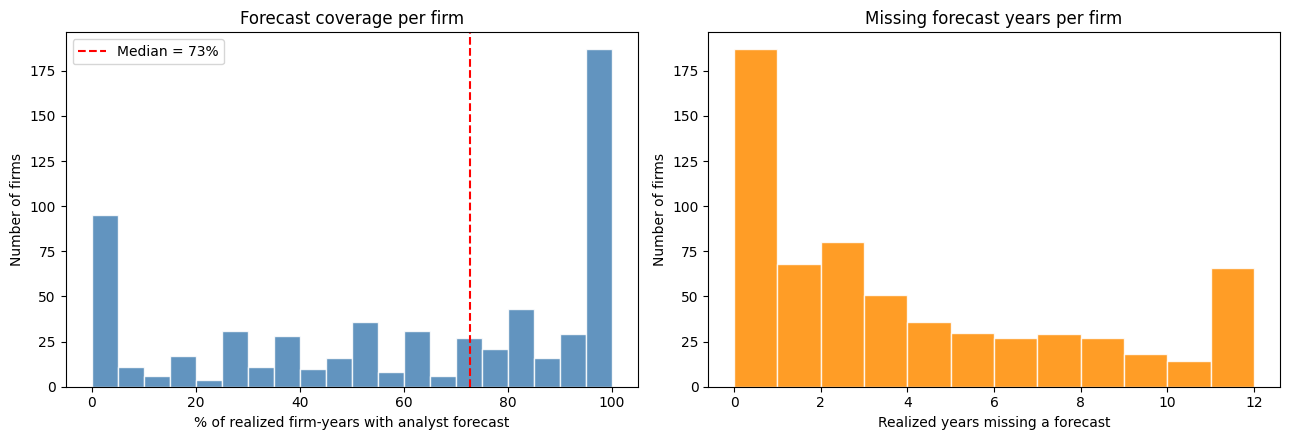

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(coverage["coverage_pct"], bins=20, color="steelblue", 
             edgecolor="white", alpha=0.85)
axes[0].axvline(coverage["coverage_pct"].median(), color="red", ls="--",
                label=f"Median = {coverage['coverage_pct'].median():.0f}%")
axes[0].set_xlabel("% of realized firm-years with analyst forecast")
axes[0].set_ylabel("Number of firms")
axes[0].set_title("Forecast coverage per firm")
axes[0].legend()

axes[1].hist(coverage["n_missing"], bins=range(0, int(coverage["n_missing"].max()) + 2),
             color="darkorange", edgecolor="white", alpha=0.85)
axes[1].set_xlabel("Realized years missing a forecast")
axes[1].set_ylabel("Number of firms")
axes[1].set_title("Missing forecast years per firm")

plt.tight_layout()
plt.show()

In [7]:
EXCHANGE_LABELS = {".OL": "Oslo", ".ST": "Stockholm", ".CO": "Copenhagen",
                   ".HE": "Helsinki", ".IC": "Iceland"}

def parse_exchange(ticker: str) -> str:
    for sfx, label in EXCHANGE_LABELS.items():
        if ticker.endswith(sfx):
            return label
    return "Other"

coverage["exchange"] = coverage["Ticker"].map(parse_exchange)

by_exch = (
    coverage.groupby("exchange")
    .agg(
        n_firms=("Ticker", "count"),
        n_zero_coverage=("coverage_pct", lambda s: int((s == 0).sum())),
        n_full_coverage=("coverage_pct", lambda s: int((s == 100).sum())),
        median_coverage_pct=("coverage_pct", "median"),
        median_missing_yrs=("n_missing", "median"),
    )
)
by_exch["pct_with_any"] = (
    (by_exch["n_firms"] - by_exch["n_zero_coverage"]) / by_exch["n_firms"] * 100
).round(1)

by_exch = by_exch[["n_firms", "pct_with_any", "n_zero_coverage",
                   "n_full_coverage", "median_coverage_pct", "median_missing_yrs"]]
print("Forecast coverage by exchange:")
print(by_exch)

Forecast coverage by exchange:
            n_firms  pct_with_any  n_zero_coverage  n_full_coverage  \
exchange                                                              
Copenhagen       86          65.1               30               28   
Helsinki        119          88.2               14               56   
Iceland          20          20.0               16                1   
Oslo            147          89.8               15               27   
Stockholm       261          92.3               20               75   

            median_coverage_pct  median_missing_yrs  
exchange                                             
Copenhagen            38.181818                 4.0  
Helsinki              90.909091                 1.0  
Iceland                0.000000                11.0  
Oslo                  60.000000                 3.0  
Stockholm             72.727273                 2.0  


In [8]:
# ═══ Which firms have zero forecast coverage? ═══

# Average AT across each firm's realized panel — used as a size proxy
mean_at = realized.groupby("Ticker")["AT"].mean()
coverage["mean_AT"] = coverage["Ticker"].map(mean_at)

zero_cov = coverage[coverage["coverage_pct"] == 0].copy()

print(f"Zero-coverage firms: {len(zero_cov)} / {len(coverage)}")
print("\nBreakdown by exchange:")
print(zero_cov.groupby("exchange").size().sort_values(ascending=False))

print("\nSize comparison (mean of mean_AT, in reporting units):")
print(f"  Zero-coverage firms:   {zero_cov['mean_AT'].mean():>12,.0f}")
print(f"  Any-coverage firms:    {coverage.loc[coverage['coverage_pct'] > 0, 'mean_AT'].mean():>12,.0f}")
print(f"  Full-coverage firms:   {coverage.loc[coverage['coverage_pct'] == 100, 'mean_AT'].mean():>12,.0f}")

# Save the zero-coverage list for an audit pass
zero_cov[["Ticker", "exchange", "n_realized_years", "first_realized",
          "last_realized", "mean_AT"]].to_csv(
    BASE_DIR / "zero_coverage_firms.csv", index=False
)
print(f"\nSaved zero-coverage firm list to: {BASE_DIR / 'zero_coverage_firms.csv'}")

Zero-coverage firms: 95 / 633

Breakdown by exchange:
exchange
Copenhagen    30
Stockholm     20
Iceland       16
Oslo          15
Helsinki      14
dtype: int64

Size comparison (mean of mean_AT, in reporting units):
  Zero-coverage firms:          4,255
  Any-coverage firms:          25,563
  Full-coverage firms:         55,776

Saved zero-coverage firm list to: /Users/sondregrontvedt/Documents/Industriell Økonomi og Teknologiledelse/excel_extract_project/modelling/analysis/zero_coverage_firms.csv


In [9]:
# ═══ Coverage by size decile ═══
# Expectation: monotonic — bigger firms have more analyst attention.
# Strong monotonicity here is the expected pattern, NOT a bug.

cov_sized = coverage.dropna(subset=["mean_AT"]).copy()
cov_sized["size_decile"] = pd.qcut(cov_sized["mean_AT"], q=10, labels=False) + 1

by_size = cov_sized.groupby("size_decile").agg(
    n_firms=("Ticker", "count"),
    pct_with_any=("coverage_pct", lambda s: (s > 0).mean() * 100),
    median_coverage_pct=("coverage_pct", "median"),
    median_AT=("mean_AT", "median"),
).round(1)

print("Coverage by size decile (1 = smallest, 10 = largest):")
print(by_size)

Coverage by size decile (1 = smallest, 10 = largest):
             n_firms  pct_with_any  median_coverage_pct  median_AT
size_decile                                                       
1                 64          75.0                 27.3      215.8
2                 63          85.7                 37.5      459.9
3                 63          85.7                 54.5      859.5
4                 63          68.3                 45.5     1503.8
5                 64          82.8                 61.8     2409.3
6                 63          85.7                 75.0     4100.8
7                 63          85.7                 77.8     7540.1
8                 63          88.9                 83.3    14645.1
9                 63          92.1                100.0    27712.5
10                64         100.0                100.0   101979.5


In [10]:
# ═══ Year-by-year coverage trend ═══

yearly_cov = (
    realized.assign(has_forecast=realized["cfo_forecast_scaled"].notna())
    .groupby("Year")
    .agg(
        n_firm_years=("Ticker", "count"),
        n_with_forecast=("has_forecast", "sum"),
    )
)
yearly_cov["pct_covered"] = (
    yearly_cov["n_with_forecast"] / yearly_cov["n_firm_years"] * 100
).round(1)
print("Year-by-year forecast coverage:")
print(yearly_cov)

Year-by-year forecast coverage:
      n_firm_years  n_with_forecast  pct_covered
Year                                            
2013           434              223         51.4
2014           447              238         53.2
2015           482              263         54.6
2016           509              305         59.9
2017           529              329         62.2
2018           547              340         62.2
2019           571              358         62.7
2020           591              363         61.4
2021           616              403         65.4
2022           631              434         68.8
2023           630              447         71.0


In [11]:
# ═══ Firm-year missingness across the FULL panel (no zero-coverage exclusion) ═══

# Total firm-years in the analysis window
full = panel[panel["Year"] >= START_YEAR].copy()

n_total      = len(full)
n_forecast   = full["cfo_forecast_scaled"].notna().sum()
n_realized   = full["CFO_lead1_scaled"].notna().sum()
n_both       = (full["cfo_forecast_scaled"].notna()
                & full["CFO_lead1_scaled"].notna()).sum()
n_neither    = (full["cfo_forecast_scaled"].isna()
                & full["CFO_lead1_scaled"].isna()).sum()
n_only_fcst  = (full["cfo_forecast_scaled"].notna()
                & full["CFO_lead1_scaled"].isna()).sum()
n_only_real  = (full["cfo_forecast_scaled"].isna()
                & full["CFO_lead1_scaled"].notna()).sum()

print(f"Full panel firm-year missingness ({full['Year'].min()}–{full['Year'].max()}):")
print(f"  Total firm-years:          {n_total:>5,}")
print(f"  Unique firms:              {full['Ticker'].nunique():>5,}")
print()
print(f"  Has analyst forecast:      {n_forecast:>5,}  ({n_forecast / n_total * 100:5.1f}%)")
print(f"  Has realized CFO_t+1:      {n_realized:>5,}  ({n_realized / n_total * 100:5.1f}%)")
print(f"  Has both:                  {n_both:>5,}  ({n_both / n_total * 100:5.1f}%)")
print(f"  Has only forecast:         {n_only_fcst:>5,}  ({n_only_fcst / n_total * 100:5.1f}%)")
print(f"  Has only realized:         {n_only_real:>5,}  ({n_only_real / n_total * 100:5.1f}%)")
print(f"  Has neither:               {n_neither:>5,}  ({n_neither / n_total * 100:5.1f}%)")

print("\nMissingness by year (firm-years missing analyst forecast):")
yearly_full = (
    full.assign(missing_forecast=full["cfo_forecast_scaled"].isna())
    .groupby("Year").agg(
        n_firm_years=("Ticker", "count"),
        n_missing_forecast=("missing_forecast", "sum"),
    )
)
yearly_full["pct_missing"] = (
    yearly_full["n_missing_forecast"] / yearly_full["n_firm_years"] * 100
).round(1)
print(yearly_full)

Full panel firm-year missingness (2013–2024):
  Total firm-years:          6,816
  Unique firms:                633

  Has analyst forecast:      4,180  ( 61.3%)
  Has realized CFO_t+1:      5,987  ( 87.8%)
  Has both:                  3,703  ( 54.3%)
  Has only forecast:           477  (  7.0%)
  Has only realized:         2,284  ( 33.5%)
  Has neither:                 352  (  5.2%)

Missingness by year (firm-years missing analyst forecast):
      n_firm_years  n_missing_forecast  pct_missing
Year                                               
2013           447                 224         50.1
2014           482                 244         50.6
2015           510                 247         48.4
2016           526                 221         42.0
2017           547                 218         39.9
2018           570                 230         40.4
2019           591                 233         39.4
2020           617                 254         41.2
2021           632               

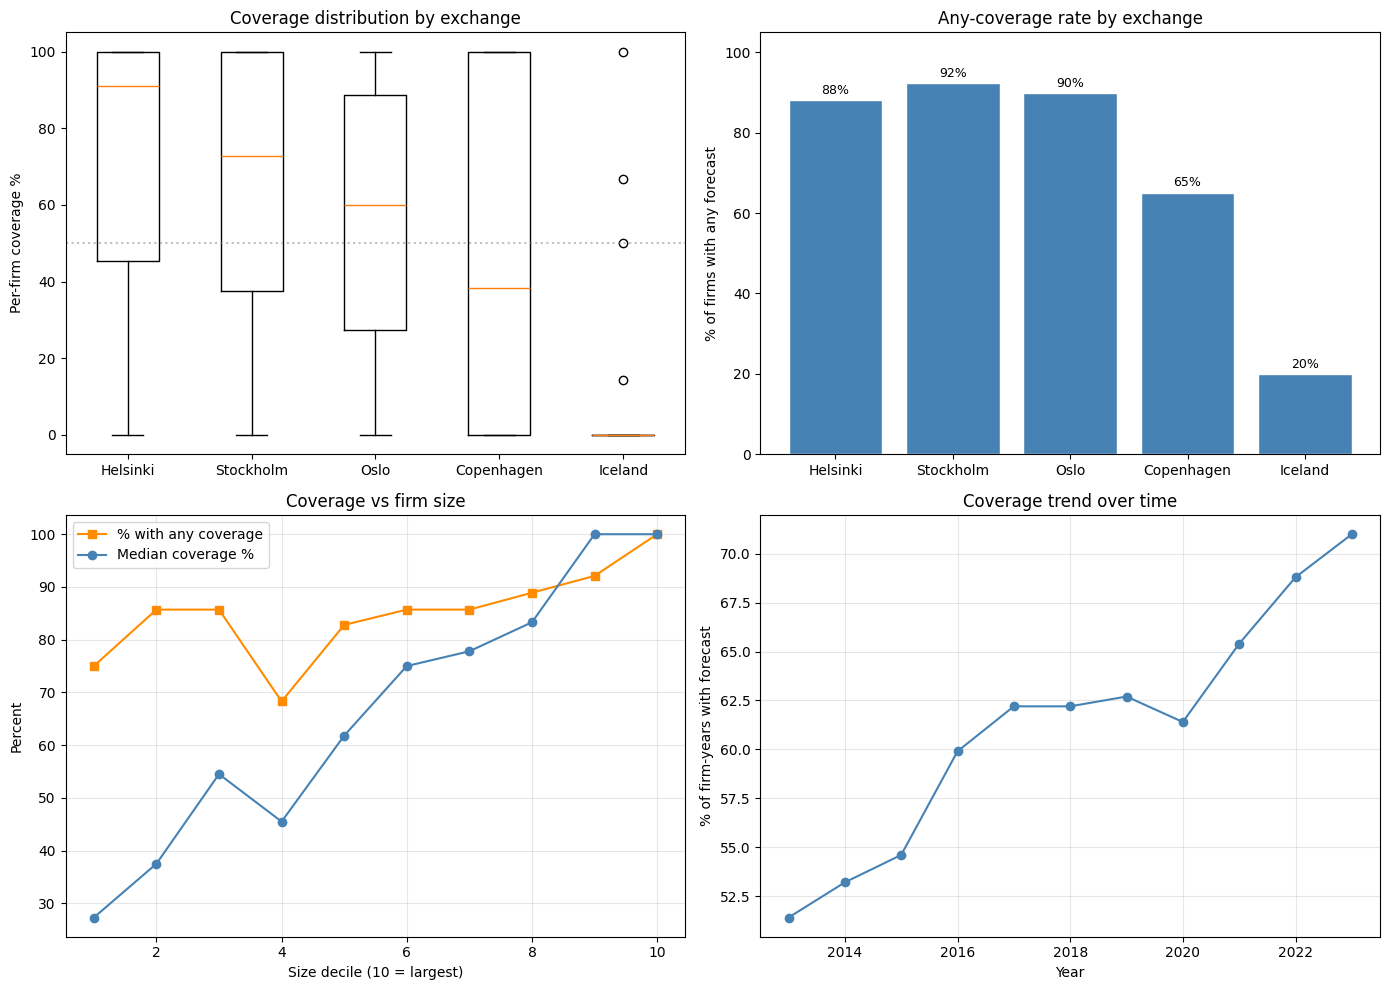

In [12]:
# ═══ Visual summary ═══

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (1) Coverage % distribution by exchange (boxplot)
exch_order = (coverage.groupby("exchange")["coverage_pct"].median()
              .sort_values(ascending=False).index.tolist())
data = [coverage.loc[coverage["exchange"] == e, "coverage_pct"] for e in exch_order]
axes[0, 0].boxplot(data, tick_labels=exch_order)
axes[0, 0].set_ylabel("Per-firm coverage %")
axes[0, 0].set_title("Coverage distribution by exchange")
axes[0, 0].axhline(50, color="gray", ls=":", alpha=0.5)

# (2) Any-coverage rate by exchange (bar)
pct_any = (coverage.assign(any_cov=coverage["coverage_pct"] > 0)
           .groupby("exchange")["any_cov"].mean() * 100).reindex(exch_order)
axes[0, 1].bar(pct_any.index, pct_any.values, color="steelblue", edgecolor="white")
axes[0, 1].set_ylabel("% of firms with any forecast")
axes[0, 1].set_title("Any-coverage rate by exchange")
for x, y in zip(pct_any.index, pct_any.values):
    axes[0, 1].text(x, y + 1.5, f"{y:.0f}%", ha="center", fontsize=9)
axes[0, 1].set_ylim(0, 105)

# (3) Coverage vs size decile
axes[1, 0].plot(by_size.index, by_size["pct_with_any"], "s-",
                color="darkorange", label="% with any coverage")
axes[1, 0].plot(by_size.index, by_size["median_coverage_pct"], "o-",
                color="steelblue", label="Median coverage %")
axes[1, 0].set_xlabel("Size decile (10 = largest)")
axes[1, 0].set_ylabel("Percent")
axes[1, 0].set_title("Coverage vs firm size")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# (4) Coverage trend over time
axes[1, 1].plot(yearly_cov.index, yearly_cov["pct_covered"], "o-",
                color="steelblue")
axes[1, 1].set_xlabel("Year")
axes[1, 1].set_ylabel("% of firm-years with forecast")
axes[1, 1].set_title("Coverage trend over time")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
# --------------------------------------------------
# Load announcement dates
# --------------------------------------------------

ann_all = pd.read_csv(INPUT_DIR_PANEL / "data/announcement_dates.csv")

ann_all["Ticker"] = ann_all["Ticker"].astype(str).str.strip()
raw["Ticker"] = raw["Ticker"].astype(str).str.strip()

ann_all["AnnouncementDate"] = pd.to_datetime(ann_all["AnnouncementDate"], errors="coerce")
ann_all["PeriodEndDate"] = pd.to_datetime(ann_all["PeriodEndDate"], errors="coerce")
ann_all["FiscalYear"] = ann_all["FiscalYear"].astype(int)

raw["snapshot_date"] = pd.to_datetime(raw["snapshot_date"], errors="coerce")

ann = ann_all[
    (ann_all["FiscalYear"] >= 2013) &
    (ann_all["FiscalYear"] <= 2024)
].copy()

ann = ann.sort_values(["Ticker", "FiscalYear"])

# --------------------------------------------------
# Load / prepare analyst forecasts
# --------------------------------------------------

df = raw.merge(ann, on="Ticker", how="left")

df["announcement_year"] = df["AnnouncementDate"].dt.year

df["forecast_window_start"] = df["AnnouncementDate"]

df["forecast_window_end"] = pd.to_datetime(
    df["announcement_year"].astype("Int64").astype(str) + "-06-30",
    errors="coerce"
)

df = df[
    (df["snapshot_date"] > df["AnnouncementDate"]) &
    (df["snapshot_date"] >= df["forecast_window_start"]) &
    (df["snapshot_date"] <= df["forecast_window_end"]) &
    (df["cfo_forecast"].notna())
].copy()

df = df.sort_values(["Ticker", "FiscalYear", "snapshot_date"])

df_final = (
    df.groupby(["Ticker", "FiscalYear"], as_index=False)
      .last()
)

# --------------------------------------------------
# Yearly coverage table
# --------------------------------------------------

coverage = df_final.groupby("FiscalYear")["Ticker"].nunique()
total = ann.groupby("FiscalYear")["Ticker"].nunique()

coverage = coverage.reindex(total.index).fillna(0).astype(int)

coverage_table = pd.DataFrame({
    "Total Firms": total,
    "Covered Firms": coverage
})

coverage_table["Coverage Rate"] = (
    coverage_table["Covered Firms"] / coverage_table["Total Firms"]
)

coverage_table

,Total Firms,Covered Firms,Coverage Rate
FiscalYear,,,
2013,259,202,0.779923
2014,261,225,0.862069
2015,292,250,0.856164
2016,316,270,0.854430
2017,364,320,0.879121
2018,392,342,0.872449
2019,409,349,0.853301
2020,436,366,0.839450
2021,487,396,0.813142


In [14]:
# --------------------------------------------------
# Firm-level coverage diagnostics
# --------------------------------------------------

firms_with_coverage = df_final["Ticker"].nunique()
years_per_firm = df_final.groupby("Ticker")["FiscalYear"].nunique()
total_years = ann["FiscalYear"].nunique()

# Strict full coverage: firm must have valid coverage every year from 2013–2024
full_coverage_strict = (years_per_firm == total_years).sum()

# Firm-specific panel window from announcement data
firm_window = (
    ann.groupby("Ticker")["FiscalYear"]
       .agg(first_year="min", last_year="max")
       .reset_index()
)

firm_window["possible_years"] = (
    firm_window["last_year"] - firm_window["first_year"] + 1
)

firm_coverage = firm_window.merge(
    years_per_firm.rename("covered_years"),
    on="Ticker",
    how="left"
)

firm_coverage["covered_years"] = (
    firm_coverage["covered_years"]
    .fillna(0)
    .astype(int)
)

firm_coverage["full_coverage_conditional"] = (
    firm_coverage["covered_years"] == firm_coverage["possible_years"]
)

conditional_full_coverage = firm_coverage["full_coverage_conditional"].sum()

In [15]:
# --------------------------------------------------
# No-gap coverage through 2024
# --------------------------------------------------

coverage_years = (
    df_final.groupby("Ticker")["FiscalYear"]
    .apply(lambda x: sorted(x.astype(int).unique().tolist()))
    .reset_index(name="covered_year_list")
)

coverage_years["first_covered_year"] = coverage_years["covered_year_list"].apply(min)
coverage_years["last_covered_year"] = coverage_years["covered_year_list"].apply(max)

coverage_years["expected_year_list"] = coverage_years["first_covered_year"].apply(
    lambda y: list(range(y, 2025))
)

coverage_years["full_no_gap_until_2024"] = (
    (coverage_years["last_covered_year"] == 2024) &
    (coverage_years["covered_year_list"] == coverage_years["expected_year_list"])
)

valid_no_gap_firms = coverage_years.loc[
    coverage_years["full_no_gap_until_2024"],
    "Ticker"
]

In [16]:
# --------------------------------------------------
# Full firm-year panel with announcement dates and valid CFO forecasts
# --------------------------------------------------

panel = ann.merge(
    df_final[[
        "Ticker",
        "FiscalYear",
        "snapshot_date",
        "cfo_forecast",
        "forecast_window_start",
        "forecast_window_end"
    ]],
    on=["Ticker", "FiscalYear"],
    how="left"
)

panel = panel.rename(columns={
    "snapshot_date": "ForecastDate"
})

panel["has_valid_cfo_forecast"] = panel["cfo_forecast"].notna().astype(int)

clean_panel = panel.dropna(
    subset=["AnnouncementDate", "ForecastDate", "cfo_forecast"]
).copy()

# No-gap clean panel
clean_panel_no_gaps = clean_panel[
    clean_panel["Ticker"].isin(valid_no_gap_firms)
].copy()

In [17]:
# --------------------------------------------------
# Export
# --------------------------------------------------

clean_panel_no_gaps.to_csv(
    BASE_DIR / "cfo_forecast_complete_cases_no_gaps_until_2024.csv",
    index=False
)

# --------------------------------------------------
# Print summary
# --------------------------------------------------

print("Sample period: 2013–2024")
print(f"Rows in full panel: {len(panel)}")
print(f"Rows with complete valid CFO forecasts: {len(clean_panel)}")
print(f"Firms with any valid CFO forecast: {firms_with_coverage}")
print(f"Strict full coverage, 2013–2024: {full_coverage_strict}")
print(f"Conditional full coverage: {conditional_full_coverage}")
print(f"Rows in no-gap clean panel: {len(clean_panel_no_gaps)}")

coverage_table

Sample period: 2013–2024
Rows in full panel: 4735
Rows with complete valid CFO forecasts: 4065
Firms with any valid CFO forecast: 512
Strict full coverage, 2013–2024: 147
Conditional full coverage: 313
Rows in no-gap clean panel: 3090


,Total Firms,Covered Firms,Coverage Rate
FiscalYear,,,
2013,259,202,0.779923
2014,261,225,0.862069
2015,292,250,0.856164
2016,316,270,0.854430
2017,364,320,0.879121
2018,392,342,0.872449
2019,409,349,0.853301
2020,436,366,0.839450
2021,487,396,0.813142


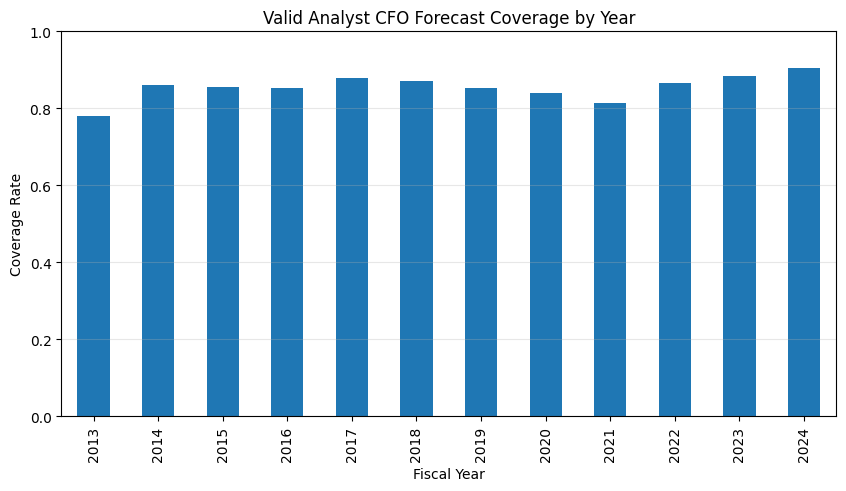

In [18]:
plt.figure(figsize=(10, 5))
coverage_table["Coverage Rate"].plot(kind="bar")

plt.title("Valid Analyst CFO Forecast Coverage by Year")
plt.xlabel("Fiscal Year")
plt.ylabel("Coverage Rate")
plt.ylim(0, 1)
plt.grid(axis="y", alpha=0.3)

plt.show()

<Figure size 1000x500 with 0 Axes>

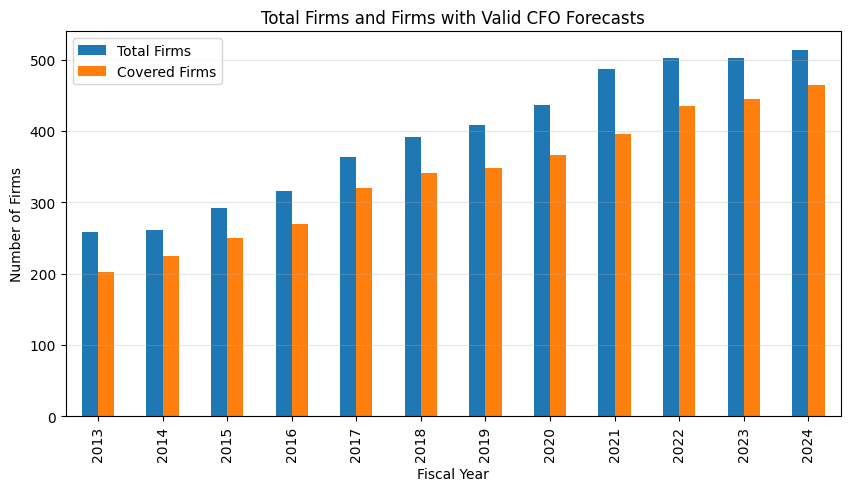

In [19]:
plt.figure(figsize=(10, 5))

coverage_table[["Total Firms", "Covered Firms"]].plot(kind="bar", figsize=(10, 5))

plt.title("Total Firms and Firms with Valid CFO Forecasts")
plt.xlabel("Fiscal Year")
plt.ylabel("Number of Firms")
plt.grid(axis="y", alpha=0.3)

plt.show()

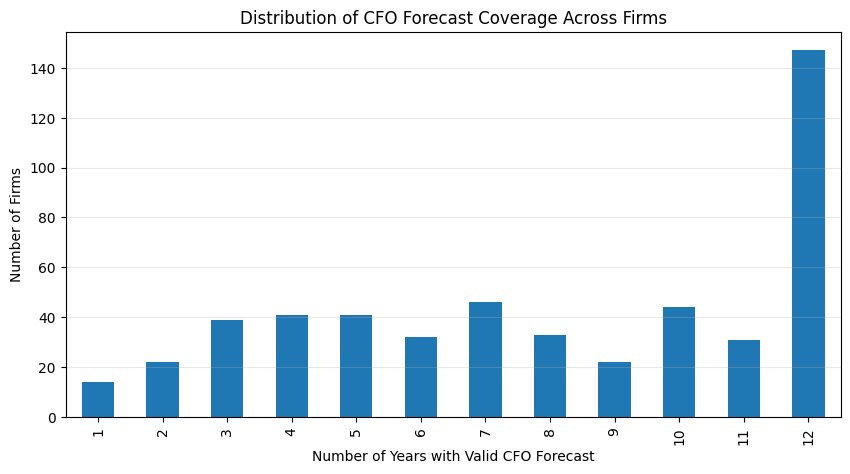

In [20]:
coverage_dist = years_per_firm.value_counts().sort_index()

plt.figure(figsize=(10, 5))
coverage_dist.plot(kind="bar")

plt.title("Distribution of CFO Forecast Coverage Across Firms")
plt.xlabel("Number of Years with Valid CFO Forecast")
plt.ylabel("Number of Firms")
plt.grid(axis="y", alpha=0.3)

plt.show()

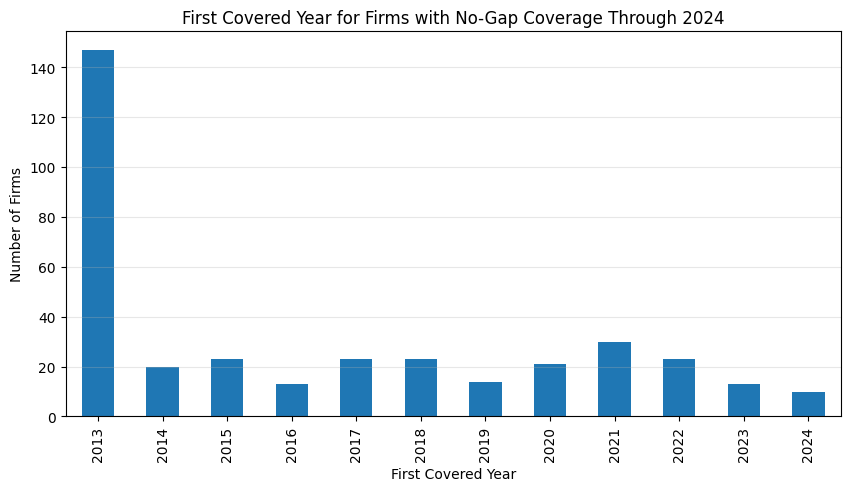

In [21]:
no_gap_start_dist = (
    coverage_years.loc[coverage_years["full_no_gap_until_2024"], "first_covered_year"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
no_gap_start_dist.plot(kind="bar")

plt.title("First Covered Year for Firms with No-Gap Coverage Through 2024")
plt.xlabel("First Covered Year")
plt.ylabel("Number of Firms")
plt.grid(axis="y", alpha=0.3)

plt.show()

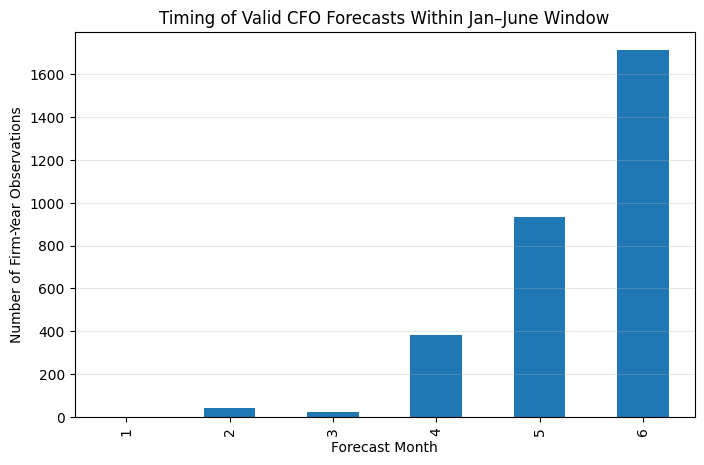

In [22]:
clean_panel_no_gaps["ForecastMonth"] = clean_panel_no_gaps["ForecastDate"].dt.month

month_dist = clean_panel_no_gaps["ForecastMonth"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
month_dist.plot(kind="bar")

plt.title("Timing of Valid CFO Forecasts Within Jan–June Window")
plt.xlabel("Forecast Month")
plt.ylabel("Number of Firm-Year Observations")
plt.grid(axis="y", alpha=0.3)

plt.show()

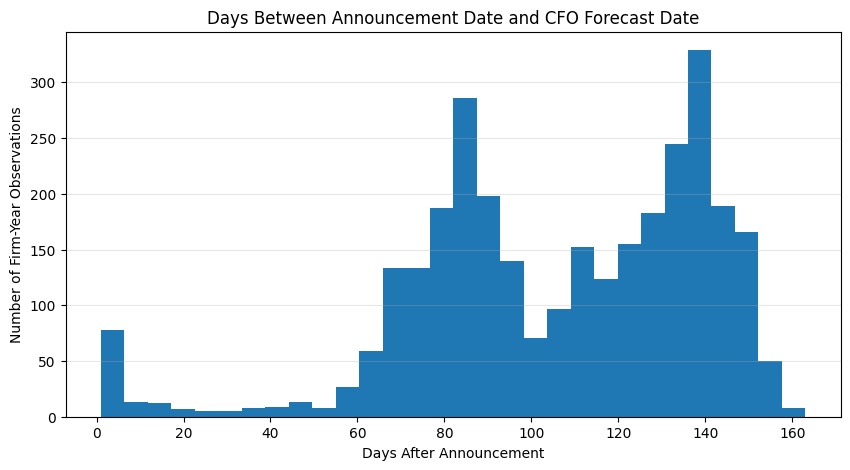

In [23]:
clean_panel_no_gaps["DaysAfterAnnouncement"] = (
    clean_panel_no_gaps["ForecastDate"] - clean_panel_no_gaps["AnnouncementDate"]
).dt.days

plt.figure(figsize=(10, 5))
clean_panel_no_gaps["DaysAfterAnnouncement"].plot(kind="hist", bins=30)
plt.title("Days Between Announcement Date and CFO Forecast Date")
plt.xlabel("Days After Announcement")
plt.ylabel("Number of Firm-Year Observations")
plt.grid(axis="y", alpha=0.3)

plt.show()

In [24]:
# --------------------------------------------------
# Validate announcement-restricted analyst CFO forecasts
# --------------------------------------------------

accounting_panel = pd.read_csv(
    INPUT_DIR_PANEL / "results/extraction_static/prepared_step2_input.csv"
)

accounting_panel = compute_wca(accounting_panel)
accounting_panel = build_regressors(accounting_panel, include_lead=True)

accounting_panel["avg_assets"] = (
    accounting_panel["AT"] +
    accounting_panel.groupby("Ticker")["AT"].shift(1)
) / 2

# Restrict to analysis window AFTER lags/leads are constructed
accounting_panel = accounting_panel[
    accounting_panel["Year"] >= START_YEAR
].copy()

In [25]:
# --------------------------------------------------
# Use announcement-restricted CFO forecasts
# --------------------------------------------------

forecast = clean_panel_no_gaps.copy()

# FiscalYear t row contains forecast for CFO_{t+1}
forecast["Year"] = forecast["FiscalYear"]

forecast = forecast.rename(columns={
    "cfo_forecast": "cfo_forecast_pre"
})

# Merge forecast onto accounting panel
accounting_panel = accounting_panel.merge(
    forecast[[
        "Ticker",
        "Year",
        "cfo_forecast_pre",
        "ForecastDate",
        "AnnouncementDate"
    ]],
    on=["Ticker", "Year"],
    how="left"
)

# Scale forecast by average assets
accounting_panel["cfo_forecast_scaled"] = (
    accounting_panel["cfo_forecast_pre"] / accounting_panel["avg_assets"]
)

In [26]:
# --------------------------------------------------
# Compare analyst forecast to realized CFO_{t+1}
# --------------------------------------------------

val = accounting_panel.dropna(
    subset=["cfo_forecast_scaled", "CFO_lead1_scaled"]
).copy()

print(f"Validation sample: {len(val)} firm-years with both forecast and realized CFO")
print(f"Years covered: {val['Year'].min()}–{val['Year'].max()}")
print(f"Unique firms: {val['Ticker'].nunique()}")

val["error"] = val["cfo_forecast_scaled"] - val["CFO_lead1_scaled"]
val["abs_error"] = val["error"].abs()
val["pct_error"] = val["error"] / val["CFO_lead1_scaled"].abs()

print("\nForecast accuracy, scaled CFO:")
print(f"  RMSE:               {np.sqrt((val['error']**2).mean()):.4f}")
print(f"  MAE:                {val['abs_error'].mean():.4f}")
print(f"  Median |error|:     {val['abs_error'].median():.4f}")
print(f"  Mean error (bias):  {val['error'].mean():+.4f}")
print(f"  Pearson r:          {pearsonr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")
print(f"  Spearman ρ:         {spearmanr(val['cfo_forecast_scaled'], val['CFO_lead1_scaled'])[0]:.3f}")

Validation sample: 2718 firm-years with both forecast and realized CFO
Years covered: 2013–2023
Unique firms: 350

Forecast accuracy, scaled CFO:
  RMSE:               0.0909
  MAE:                0.0445
  Median |error|:     0.0253
  Mean error (bias):  +0.0078
  Pearson r:          0.817
  Spearman ρ:         0.780
